In [ ]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM,
    EsmConfig,
    PretrainedConfig,
    EsmTokenizer,
    DataCollatorForLanguageModeling,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [ ]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm, get_fairesm_state_dict

In [ ]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile
from scipy.stats import pearsonr

# Load CovFit model

In [ ]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [ ]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")

In [ ]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    state_dict = torch.load(MODEL_PATH, map_location=device)

    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)

    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]

    esm_fine_tuned.load_state_dict(state_dict)
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [ ]:
esm_fine_tuned = get_model()
# fairesm_state_dict = get_fairesm_state_dict(esm_fine_tuned.state_dict(), esm_config)
# save_state_dict = True
# if save_state_dict:
#     torch.save(fairesm_state_dict, "./covfit_stuff/models/covfit_esm_statedict.pt")

In [ ]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [ ]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [ ]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [ ]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [ ]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [ ]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [ ]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt",
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [ ]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [ ]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [ ]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]

    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4498
torch.Size([4498, 1024])


In [ ]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [ ]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"

    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [ ]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [ ]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_s)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

#### Given some sequence with name seq_names[i], its corresponding sequence is all_uniq_seqs[seq_idxs[i]]
#### Given some sequence with index uniq_seqs[i], its corresponding name(s) is get_rev_names(i)

In [ ]:
logit_id = original_task_id_infos["fitness_USA"]

In [ ]:
mlr_data = pd.read_csv("../data/steering/parent_child_fitness.tsv",sep = "\t")
# fixing small bug
mlr_data.loc[mlr_data["spike"] == "-66. + Median[{}]", "spike"] = -66

In [ ]:
def calc_stats(x,y,xrange):
    x = np.array(x)
    y = np.array(y)

    idx = (x >= xrange[0]) & (x <= xrange[1])
    x = x[idx]
    y = y[idx]

    N = x.shape[0]

    correlation = pearsonr(x,y).statistic
    x = np.array(x)[:,None]
    w = np.linalg.lstsq(np.hstack((x, np.ones((N,1)))), y, rcond=None)[0]
    xx = np.linspace(xrange[0], xrange[1]).T

    return correlation, w[0]*xx + w[1]

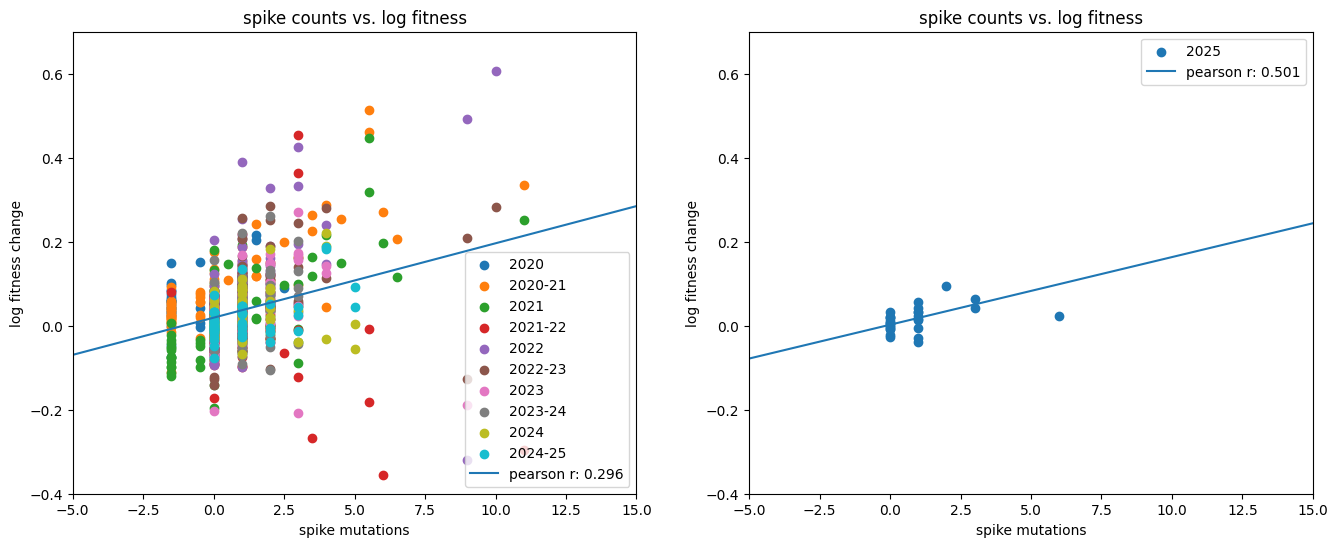

In [ ]:
xlow = -5
xhigh = 15

fig, ax = plt.subplots(1,2,figsize=(16,6))
for timepoint in np.unique(mlr_data["datapoint"]):
    time_idx = (mlr_data["datapoint"] == timepoint)
    if timepoint < "2025":
        ax[0].scatter([float(x) for x in mlr_data["spike"][time_idx]], mlr_data["fitness"][time_idx], label=timepoint)
    else:
        ax[1].scatter([float(x) for x in mlr_data["spike"][time_idx]], mlr_data["fitness"][time_idx], label=timepoint)

time_idx = mlr_data["datapoint"] <= "2024"
corr0, best_fit0 = calc_stats([float(x) for x in mlr_data["spike"][time_idx]], mlr_data["fitness"][time_idx], [xlow,xhigh])
ax[0].plot(np.linspace(xlow, xhigh), best_fit0, label="pearson r: %-.3f"%corr0)

time_idx = np.logical_not(time_idx)
corr1, best_fit1 = calc_stats([float(x) for x in mlr_data["spike"][time_idx]], mlr_data["fitness"][time_idx], [xlow,xhigh])
ax[1].plot(np.linspace(xlow, xhigh), best_fit1, label="pearson r: %-.3f"%corr1)

for a in ax:
    a.set_ylim([-.4, 0.7])
    a.set_xlim([xlow,xhigh])
    a.set_xlabel("spike mutations")
    a.set_ylabel("log fitness change")
    a.set_title("spike counts vs. log fitness")
    a.legend()
plt.show()

In [ ]:
fasta_file = f"../data/steering/lineages.fasta"
lineage_data = load_sequences(fasta_file)
lineage_seq_names, lineage_seq = list(zip(*list(lineage_data.items())))

name_to_seq_dict = {n:s for (n,s) in zip(lineage_seq_names, lineage_seq)}

In [ ]:
tokenizing_lambda = lambda x: tokenizer(
    x, return_tensors="pt",
    return_special_tokens_mask=True,
    truncation=True,
    padding="max_length",
    max_length=CONTEXT_LEN
).input_ids.to(device)

def get_covfit_preds(parent_child, gt_fitness_vals, tokenizer=tokenizing_lambda):
    gt_fitness_vals = gt_fitness_vals.tolist()
    parent_name, child_name = list(zip(*[x.split("->") for x in parent_child.tolist()]))

    # only get names with vals in dict
    valid_names = [i for i,n in enumerate(parent_name) if name_to_seq_dict.get(n,None)]
    valid_names = [i for i in valid_names if name_to_seq_dict.get(child_name[i],None)]

    parent_seqs = tokenizer([name_to_seq_dict[parent_name[i]] for i in valid_names])
    child_seqs = tokenizer([name_to_seq_dict[child_name[i]] for i in valid_names])

    preds = esm_fine_tuned(child_seqs).logits[:,logit_id] - esm_fine_tuned(parent_seqs).logits[:,logit_id]
    torch.cuda.empty_cache()
    return preds.cpu().numpy(), [gt_fitness_vals[i] for i in valid_names]

...........


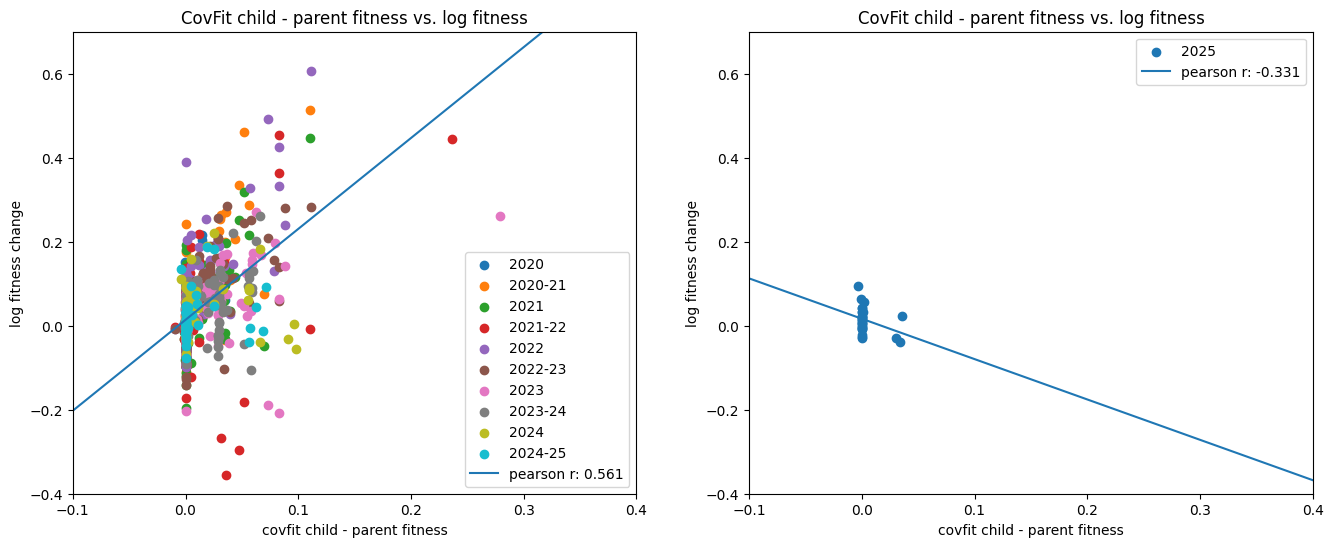

In [ ]:
xlow = -0.1
xhigh = 0.4

fig, ax = plt.subplots(1,2,figsize=(16,6))

# covfit, fitness
bef24_vals = [[], []]
aft24_vals = [[], []]

for timepoint in np.unique(mlr_data["datapoint"]):
    print(".", end="")
    time_idx = (mlr_data["datapoint"] == timepoint)

    covfit_preds, fitness_vals = get_covfit_preds(mlr_data["parent-child"][time_idx], mlr_data["fitness"][time_idx])
    if timepoint < "2025":
        ax[0].scatter(covfit_preds, fitness_vals, label=timepoint)
        bef24_vals[0].extend(covfit_preds)
        bef24_vals[1].extend(fitness_vals)
    else:
        ax[1].scatter(covfit_preds, fitness_vals, label=timepoint)
        aft24_vals[0].extend(covfit_preds)
        aft24_vals[1].extend(fitness_vals)
print()


corr0, best_fit0 = calc_stats(bef24_vals[0], bef24_vals[1], [xlow,xhigh])
ax[0].plot(np.linspace(xlow, xhigh), best_fit0, label="pearson r: %-.3f"%corr0)

corr1, best_fit1 = calc_stats(aft24_vals[0], aft24_vals[1], [xlow,xhigh])
ax[1].plot(np.linspace(xlow, xhigh), best_fit1, label="pearson r: %-.3f"%corr1)

for a in ax:
    a.set_ylim([-.4, 0.7])
    a.set_xlim([xlow,xhigh])
    a.set_xlabel("covfit child - parent fitness")
    a.set_ylabel("log fitness change")
    a.set_title("CovFit child - parent fitness vs. log fitness")
    a.legend()
plt.show()

In [ ]:
OOD_data_names = mlr_data["parent-child"][mlr_data["datapoint"] == "2025"]
parent_name, child_name = list(zip(*[x.split("->") for x in OOD_data_names.tolist()]))
OOD_data_names = list(set([*parent_name, *child_name]))

OOD_data_names = [x for x in OOD_data_names if name_to_seq_dict.get(x, None)]
OOD_seq = [name_to_seq_dict[x] for x in OOD_data_names]
OOD_data_names = [f"(OOD) {x}" for x in OOD_data_names]

In [ ]:
ID_data_names = mlr_data["parent-child"][mlr_data["datapoint"] < "2025"]
parent_name, child_name = list(zip(*[x.split("->") for x in ID_data_names.tolist()]))
ID_data_names = list(set([*parent_name, *child_name]))

ID_data_names = [x for x in ID_data_names if name_to_seq_dict.get(x, None)]
ID_seq = [name_to_seq_dict[x] for x in ID_data_names]
ID_data_names = [f"(ID) {x}" for x in ID_data_names]

In [ ]:
wt_idx = [i for i,x in enumerate(seq_names) if "wuhan" in x.lower()][0]
wt_seq = np.array(list(all_uniq_seqs[seq_idxs[wt_idx]]))[None, :]
np_seq = np.array([list(x) for x in [*ID_seq, *OOD_seq]])

In [ ]:
seq_muts = [] # List[List[str]] where each element is the number of muts from element i for wt (WuHan)
num_muts = []

diffs = np.argwhere(np_seq != wt_seq)
for s in range(np_seq.shape[0]):
    diff_aa_idx = diffs[diffs[:,0] == s][:,1] #mutations are 1-indexed
    num_muts.append(diff_aa_idx.shape[0])

    seq_muts.append([f"Spike-{wt_seq[0, x]}{x+1}{np_seq[s, x]}" if np_seq[s, x] != "-" else f"del Spike-{wt_seq[0, x]}{x+1}" for x in diff_aa_idx])

seq_muts = [str(x)[1:-1].replace("'","") for x in seq_muts]